In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, 
                              roc_auc_score, roc_curve, auc)
from src.data.load_data import load_resumes, load_jobs
from src.data.preprocess import clean_text
from src.features.match_features import compute_skill_overlap, compute_experience_match

In [2]:
resumes = load_resumes()
jobs    = joblib.load('../models/jobs_df.pkl')
print("✅ Resumes:", resumes.shape)
print("✅ Jobs:", jobs.shape)

✅ Resumes: (962, 2)
✅ Jobs: (50000, 7)


In [3]:
print("⏳ Building match features...")

rows = []
sample_jobs = jobs.sample(500, random_state=42)

for _, resume_row in resumes.iterrows():
    resume_text   = clean_text(resume_row['Resume'])
    resume_cat    = resume_row['Category']
    
    for _, job_row in sample_jobs.iterrows():
        skill_overlap    = compute_skill_overlap(resume_text, job_row['skills'])
        exp_match        = compute_experience_match(resume_text, job_row['experience'])
        
        # Label: 1 if category keyword in job title
        label = 1 if any(
            word.lower() in str(job_row['title']).lower() 
            for word in resume_cat.split()
        ) else 0
        
        rows.append({
            'skill_overlap'   : skill_overlap,
            'exp_match'       : exp_match,
            'label'           : label
        })

df_features = pd.DataFrame(rows)
print("✅ Features built:", df_features.shape)
print("Label distribution:\n", df_features['label'].value_counts())

⏳ Building match features...
✅ Features built: (481000, 3)
Label distribution:
 label
0    461164
1     19836
Name: count, dtype: int64


In [4]:
X = df_features[['skill_overlap', 'exp_match']]
y = df_features['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     92337
           1       0.00      0.00      0.00      3863

    accuracy                           0.96     96200
   macro avg       0.48      0.50      0.49     96200
weighted avg       0.92      0.96      0.94     96200

ROC-AUC: 0.5859


c:\Users\pujal\smarthire\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pujal\smarthire\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pujal\smarthire\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [5]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

# Comparison table
print("\n=== Model Comparison ===")
print(f"{'Model':<25} {'ROC-AUC'}")
print(f"{'Logistic Regression':<25} {roc_auc_score(y_test, y_prob):.4f}")
print(f"{'XGBoost':<25} {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     92337
           1       0.83      0.00      0.00      3863

    accuracy                           0.96     96200
   macro avg       0.90      0.50      0.49     96200
weighted avg       0.95      0.96      0.94     96200

ROC-AUC: 0.5966

=== Model Comparison ===
Model                     ROC-AUC
Logistic Regression       0.5859
XGBoost                   0.5966


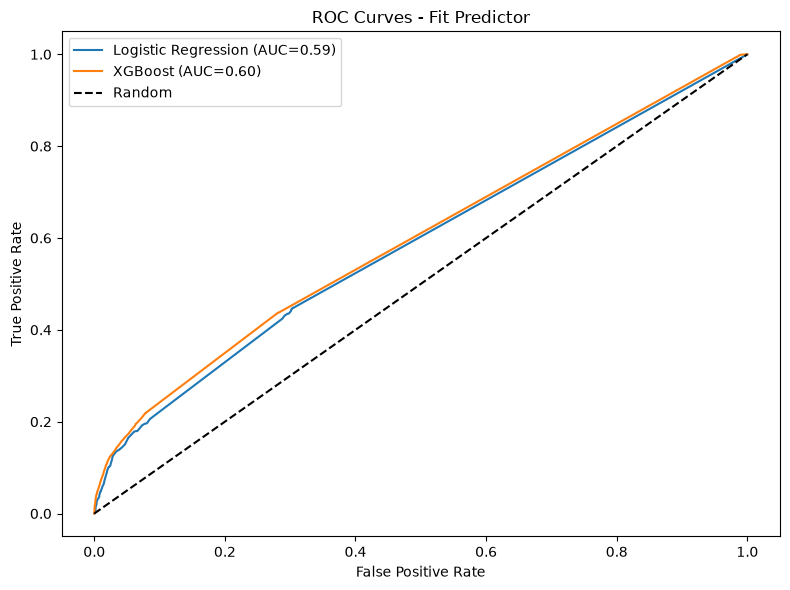

✅ ROC curve saved!


In [6]:
plt.figure(figsize=(8, 6))

# LR curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_lr, tpr_lr, 
         label=f'Logistic Regression (AUC={auc(fpr_lr,tpr_lr):.2f})')

# XGB curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, 
         label=f'XGBoost (AUC={auc(fpr_xgb,tpr_xgb):.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Fit Predictor')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/fit_predictor_roc.png')
plt.show()
print("✅ ROC curve saved!")

In [7]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(xgb, '../models/fit_predictor.pkl')
print("✅ Fit predictor saved to models/fit_predictor.pkl")

✅ Fit predictor saved to models/fit_predictor.pkl
